In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [7]:
df = pd.read_excel("/Users/miguelangel/Documents/IISChallenge/IIS-Challenge/data/raw/BaseDatos_IISE_TO.xlsx")
df.head()

,Remisión,Unidad,Operador,Ruta,Fecha Inicio (Día),Fecha Fin (Día),Inicio (Hora),Fin (Hora),km,Litros,Rend,peso
0,P-110460,3157,DESGARENNIS ORTEGA CHRISTIAN,PUEBLA -CUAUTITLAN,2026-03-23,2026-03-23,04:59:00,16:46:00,346.4,137.0,2.528467,35.995
1,P-109685,3157,DESGARENNIS ORTEGA CHRISTIAN,PUEBLA -CUAUTITLAN,2026-02-18,2026-02-18,04:48:00,21:01:00,386.8,155.5,2.487460,34.761
2,P-109704,3077,APANECATL MORENO SAUL,PUEBLA -CUAUTITLAN,2026-02-18,2026-02-18,04:58:00,20:20:00,385.2,142.0,2.712676,34.778
3,P-109662,3158,PASTRANA CARIÑO FRANCISCO SAMUEL,PUEBLA -CUAUTITLAN,2026-02-17,2026-02-17,05:00:00,23:11:00,350.4,149.5,2.343813,34.803
4,P-109576,3158,PASTRANA CARIÑO FRANCISCO SAMUEL,PUEBLA -CUAUTITLAN,2026-02-16,2026-02-16,04:58:00,22:03:00,341.6,156.5,2.182748,34.828


In [8]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones: (75, 12)

Tipos de datos:
Remisión                         str
Unidad                         int64
Operador                         str
Ruta                             str
Fecha Inicio (Día)    datetime64[us]
Fecha Fin (Día)       datetime64[us]
Inicio (Hora)                 object
Fin (Hora)                    object
km                           float64
Litros                       float64
Rend                         float64
peso                         float64
dtype: object

Valores nulos por columna:
Remisión              0
Unidad                0
Operador              0
Ruta                  0
Fecha Inicio (Día)    0
Fecha Fin (Día)       0
Inicio (Hora)         0
Fin (Hora)            0
km                    0
Litros                0
Rend                  0
peso                  0
dtype: int64


Note: Inicio y Fin (Horas) - Are object, therefor I will need to convert them

In [9]:
df.describe()

,Unidad,Fecha Inicio (Día),Fecha Fin (Día),km,Litros,Rend,peso
count,75.000000,75,75,75.000000,75.000000,75.000000,75.000000
mean,3119.093333,2026-01-26 13:45:36,2026-01-26 14:24:00,349.185333,142.686667,2.457301,34.820587
min,2934.000000,2026-01-05 00:00:00,2026-01-05 00:00:00,328.300000,124.000000,2.032884,32.204000
25%,3097.500000,2026-01-16 00:00:00,2026-01-16 00:00:00,340.950000,136.250000,2.331183,34.744500
50%,3119.000000,2026-01-26 00:00:00,2026-01-26 00:00:00,345.700000,141.000000,2.478700,34.820000
75%,3158.000000,2026-02-04 00:00:00,2026-02-04 00:00:00,352.950000,147.750000,2.558439,34.926000
max,3163.000000,2026-03-23 00:00:00,2026-03-23 00:00:00,423.600000,185.500000,3.209091,35.995000
std,37.635942,NaN,NaN,15.508617,9.833332,0.186444,0.391709


In [10]:
df.nunique()

Remisión              74
Unidad                15
Operador              15
Ruta                   1
Fecha Inicio (Día)    32
Fecha Fin (Día)       33
Inicio (Hora)         30
Fin (Hora)            69
km                    70
Litros                46
Rend                  75
peso                  67
dtype: int64

In [11]:
print("Viajes por operador:")
print(df['Operador'].value_counts())
print("\nViajes por unidad:")
print(df['Unidad'].value_counts())

Viajes por operador:
Operador
SALAZAR ORTEGA EDGAR                  11
APANECATL MORENO SAUL                 10
BELLO CORONA JUAN CARLOS               8
CUEVAS ROMERO ALFONSO                  7
ARIAS MENDOZA LUIS ENRIQUE             7
PASTRANA CARIÑO FRANCISCO SAMUEL       6
ARELLANO ALBERTO IGNACIO               6
HERNANDEZ ZAVALA JESUS FABIAN          5
DESGARENNIS ORTEGA CHRISTIAN           4
DE JESUS GARCIA CONSTANTINO            4
GALINDO GARCIA FELIPE MANUEL           3
DEL ROSARIO LUNA ANTONIO ABAD          1
BARREDA DURAN SIMON OCTAVIO            1
BONILLA PALESTINA VICTOR ALEJANDRO     1
GUZMAN JULIAN ELIAS                    1
Name: count, dtype: int64

Viajes por unidad:
Unidad
3102    11
3077    10
3163     8
3162     7
3121     7
3158     6
3113     6
3119     5
3157     4
3093     4
3089     3
3091     1
2934     1
3122     1
3120     1
Name: count, dtype: int64


In [12]:
print("Combinaciones Operador-Unidad:")
print(df.groupby('Operador')['Unidad'].unique())

Combinaciones Operador-Unidad:
Operador
APANECATL MORENO SAUL                 [3077]
ARELLANO ALBERTO IGNACIO              [3113]
ARIAS MENDOZA LUIS ENRIQUE            [3121]
BARREDA DURAN SIMON OCTAVIO           [2934]
BELLO CORONA JUAN CARLOS              [3163]
BONILLA PALESTINA VICTOR ALEJANDRO    [3122]
CUEVAS ROMERO ALFONSO                 [3162]
DE JESUS GARCIA CONSTANTINO           [3093]
DEL ROSARIO LUNA ANTONIO ABAD         [3091]
DESGARENNIS ORTEGA CHRISTIAN          [3157]
GALINDO GARCIA FELIPE MANUEL          [3089]
GUZMAN JULIAN ELIAS                   [3120]
HERNANDEZ ZAVALA JESUS FABIAN         [3119]
PASTRANA CARIÑO FRANCISCO SAMUEL      [3158]
SALAZAR ORTEGA EDGAR                  [3102]
Name: Unidad, dtype: object


Note: This dataset contains perfect confounding. ()

## Distribución del Rendimiento (km/L)

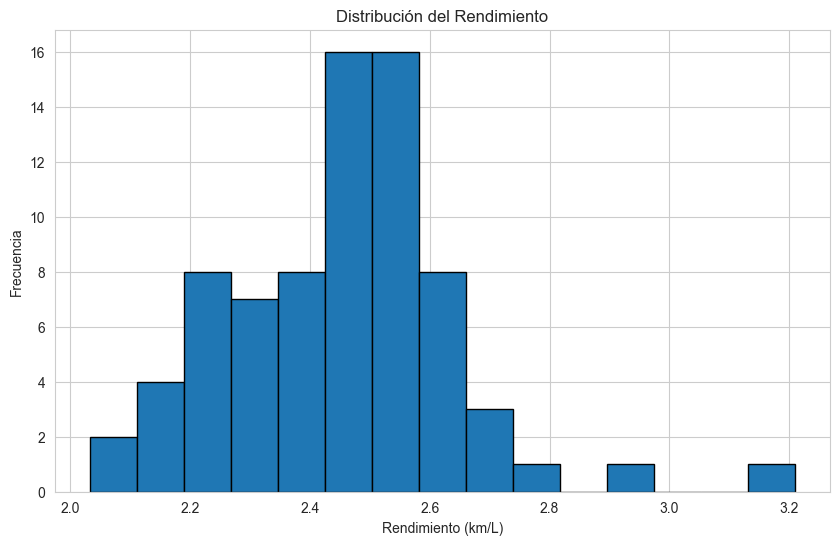

In [13]:
plt.hist(df['Rend'], bins=15, edgecolor='black')
plt.xlabel('Rendimiento (km/L)')
plt.ylabel('Frecuencia')
plt.title('Distribución del Rendimiento')
plt.show()

**Histograma:** la distribución se concentra entre 2.2 y 2.6 km/L, con una cola derecha - hay unos pocos viajes con rendimiento muy alto (3.0-3.2 km/L). Esos valores altos son outliers que vale la pena investigar: ¿quién los hizo y en qué condiciones? Quizás son los viajes de Arias Mendoza con la unidad 3121, que en el boxplot se ve que tiene un dato extremo arriba de 3.2.

## Boxplot de rendimiento por operador

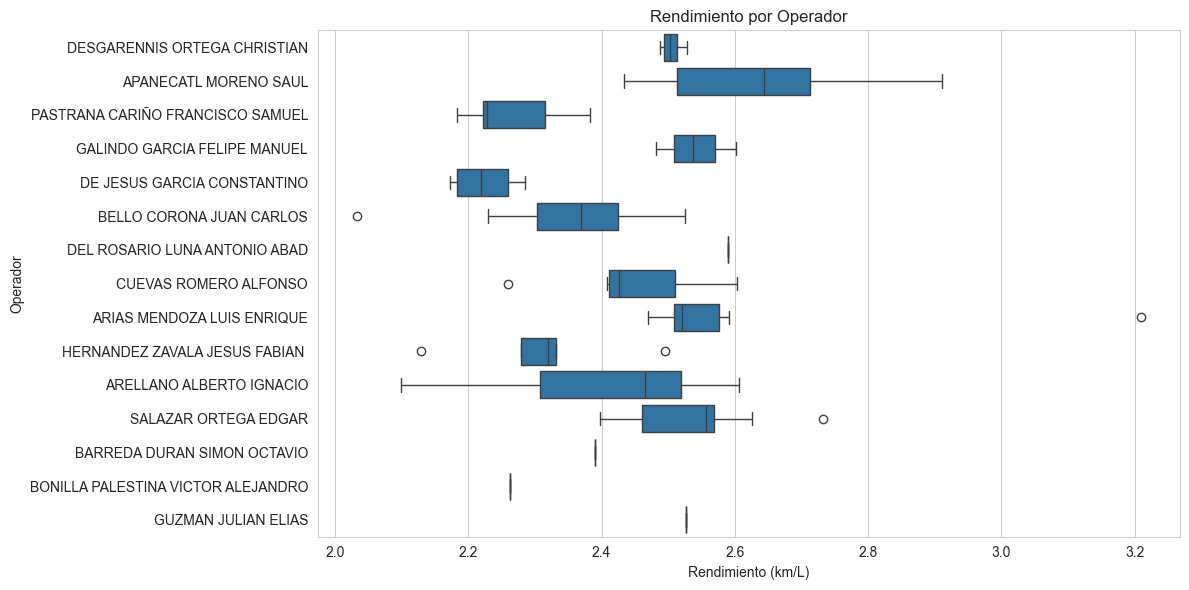

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Rend', y='Operador', data=df, orient='h')
plt.xlabel('Rendimiento (km/L)')
plt.title('Rendimiento por Operador')
plt.tight_layout()
plt.show()

**Boxplot:** Primero, los operadores con las cajas más altas (Desgarennis, Apanecatl, Arias) son los más eficientes. Segundo, Hernández Zavala y De Jesús García están consistentemente abajo de 2.3 km/L — son candidatos a entrenamiento. Tercero, Arellano y Bello Corona tienen cajas muy anchas, lo que significa que son inconsistentes: a veces manejan bien y a veces no. Los operadores con solo 1 viaje (Barreda, Bonilla, Guzmán, Del Rosario) son solo una línea — no puedes concluir nada de ellos.

## Scatter plot peso vs. rendimiento

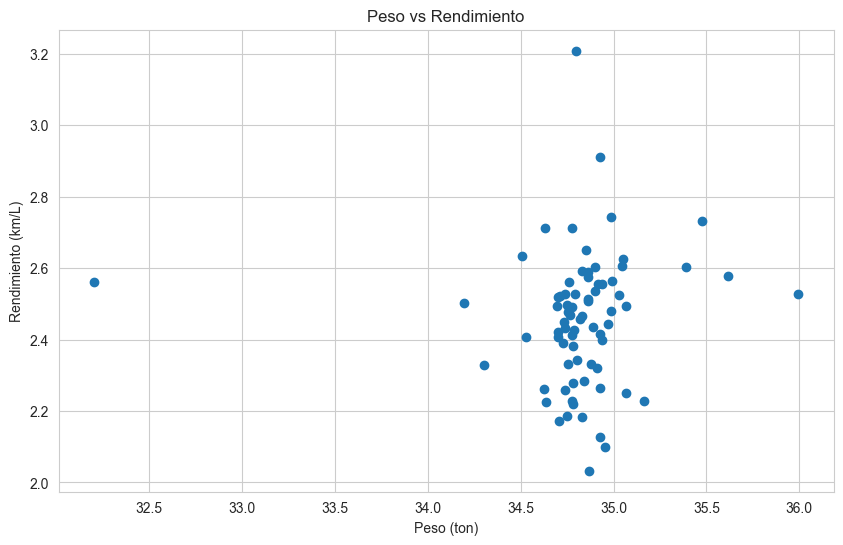

In [15]:
plt.scatter(df['peso'], df['Rend'])
plt.xlabel('Peso (ton)')
plt.ylabel('Rendimiento (km/L)')
plt.title('Peso vs Rendimiento')
plt.show()

**Scatter plot:** No hay relación clara entre peso y rendimiento.

<Axes: >

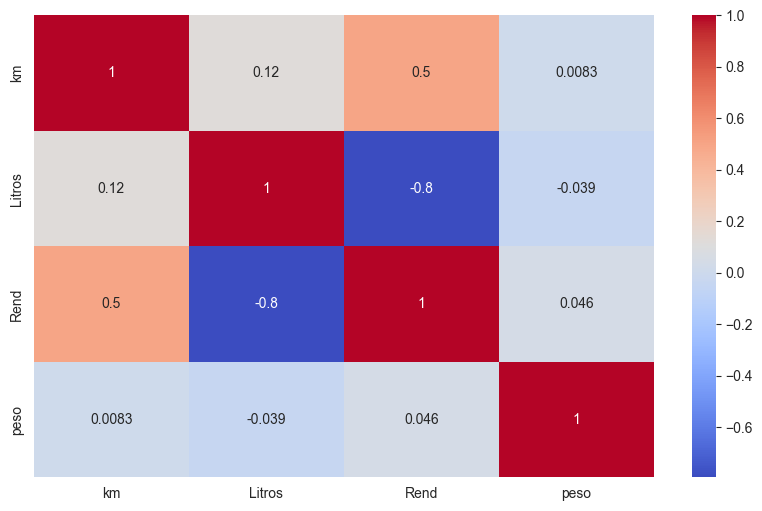

In [16]:
sns.heatmap(df[['km', 'Litros', 'Rend', 'peso']].corr(), annot=True, cmap='coolwarm')

**Descripción:** la variabilidad en consumo no se explica por peso ni por distancia. Se explica principalmente por quién maneja (y/o qué unidad usa).

## Scatter km vs. Litros:

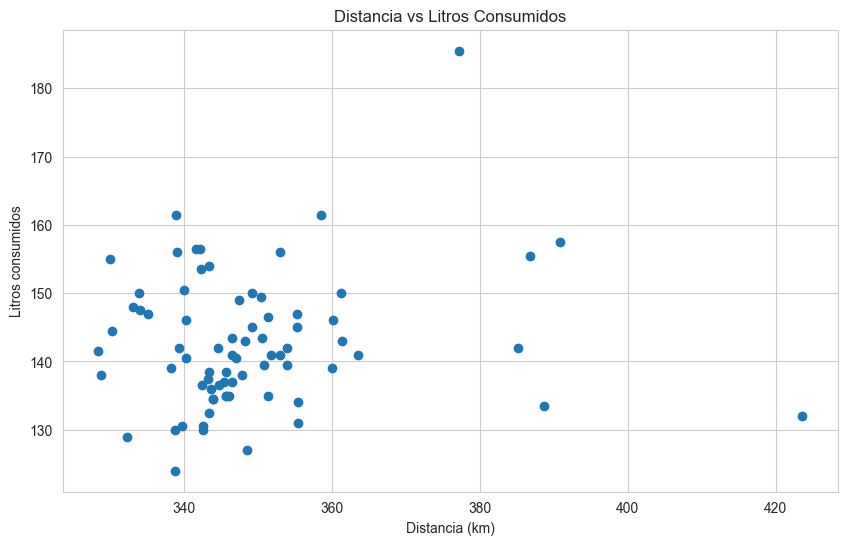

In [17]:
plt.scatter(df['km'], df['Litros'])
plt.xlabel('Distancia (km)')
plt.ylabel('Litros consumidos')
plt.title('Distancia vs Litros Consumidos')
plt.show()

## Rendimiento en el tiempo:

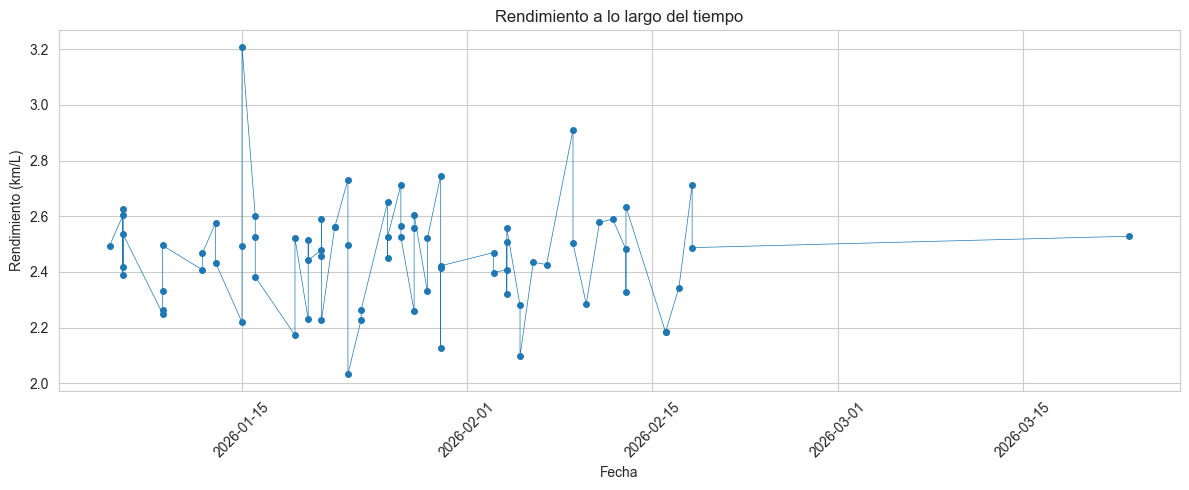

In [18]:
df_sorted = df.sort_values('Fecha Inicio (Día)')
plt.figure(figsize=(12, 5))
plt.plot(df_sorted['Fecha Inicio (Día)'], df_sorted['Rend'], marker='o', linewidth=0.5, markersize=4)
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (km/L)')
plt.title('Rendimiento a lo largo del tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Rendimiento en el tiempo:** no hay tendencia clara, ni mejora ni deterioro. Lo que sí se ve es que la mayor concentración de viajes está entre enero y mediados de febrero, y después hay muy pocos datos en marzo. La variabilidad es constante — el rendimiento sube y baja sin patrón temporal.

## Rendimiento promedio por operador

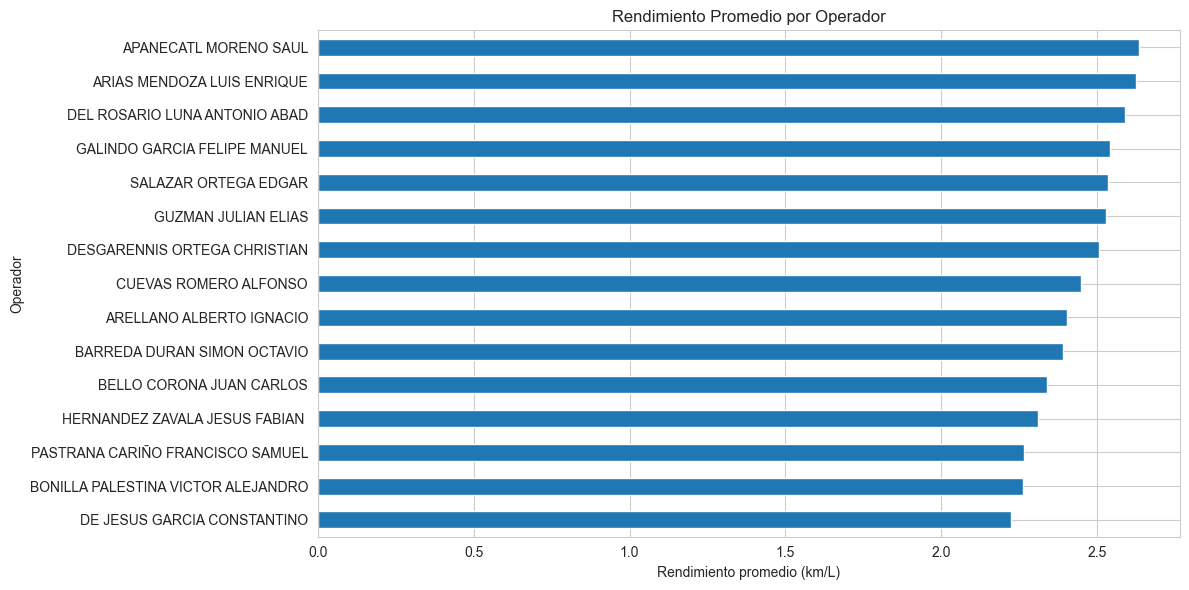

In [19]:
plt.figure(figsize=(12, 6))
df.groupby('Operador')['Rend'].mean().sort_values().plot(kind='barh')
plt.xlabel('Rendimiento promedio (km/L)')
plt.title('Rendimiento Promedio por Operador')
plt.tight_layout()
plt.show()

**Barras de rendimiento por operador:** La diferencia entre Apanecatl Moreno (~2.65 km/L) y De Jesús García (~2.15 km/L) es de medio km/L. Eso parece poco, pero en una ruta de 350 km redondos significa que De Jesús consume ~30 litros más por viaje. A $28/L, eso son $840 extra por viaje. Si hace 4 viajes al mes, son $3,360 mensuales desperdiciados solo en un operador.

## Hallazgos

El peso no explica la variabilidad porque es casi constante (~34.8 ton), la distancia tampoco la explica bien (correlación 0.12 con litros), el factor dominante es el operador/unidad con diferencias de hasta 30% en rendimiento entre el mejor y el peor, hay confusión perfecta entre operador y unidad (relación 1 a 1), y no hay tendencia temporal.

## Segunda Parte

-El rendimineto esta relacionado al conductor

**Hipotesis:** Los conductores con un buen rendimiento coinciden en sus horarios de salida

In [26]:
from datetime import time

def to_decimal_hour(t):
    if isinstance(t, time):
        return t.hour + t.minute / 60 + t.second / 3600
    # String tipo '05:02:00 a. m.' o '04:01:00 p. m.'
    t = t.strip()
    es_pm = 'p. m.' in t.lower() or 'p.m.' in t.lower()
    hora_str = t.split('a. m.')[0].split('p. m.')[0].split('a.m.')[0].split('p.m.')[0].strip()
    parts = hora_str.split(':')
    h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    if es_pm and h != 12:
        h += 12
    elif not es_pm and h == 12:
        h = 0
    return h + m / 60 + s / 3600

df['hora_inicio_decimal'] = df['Inicio (Hora)'].apply(to_decimal_hour)
df[['Operador', 'Inicio (Hora)', 'hora_inicio_decimal']].head(10)

,Operador,Inicio (Hora),hora_inicio_decimal
0,DESGARENNIS ORTEGA CHRISTIAN,04:59:00,4.983333
1,DESGARENNIS ORTEGA CHRISTIAN,04:48:00,4.800000
2,APANECATL MORENO SAUL,04:58:00,4.966667
3,PASTRANA CARIÑO FRANCISCO SAMUEL,05:00:00,5.000000
4,PASTRANA CARIÑO FRANCISCO SAMUEL,04:58:00,4.966667
5,GALINDO GARCIA FELIPE MANUEL,04:58:00,4.966667
6,DE JESUS GARCIA CONSTANTINO,05:03:00,5.050000
7,BELLO CORONA JUAN CARLOS,05:02:00,5.033333
8,APANECATL MORENO SAUL,05:00:00,5.000000
9,DEL ROSARIO LUNA ANTONIO ABAD,05:00:00,5.000000


## Scatter hora vs rendimiento:

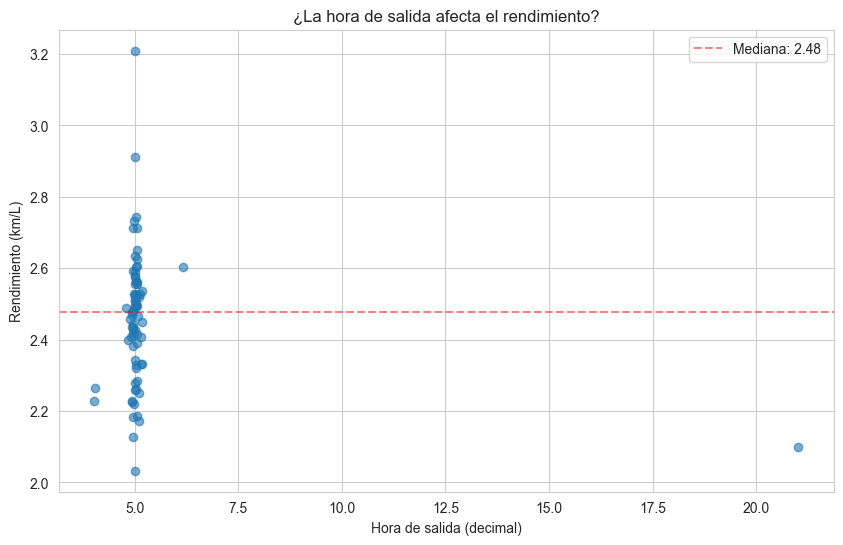

Correlación hora_inicio vs Rend: -0.200


In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df['hora_inicio_decimal'], df['Rend'], alpha=0.6)
plt.xlabel('Hora de salida (decimal)')
plt.ylabel('Rendimiento (km/L)')
plt.title('¿La hora de salida afecta el rendimiento?')
plt.axhline(y=df['Rend'].median(), color='red', linestyle='--', alpha=0.5, label=f'Mediana: {df["Rend"].median():.2f}')
plt.legend()
plt.show()

print(f"Correlación hora_inicio vs Rend: {df['hora_inicio_decimal'].corr(df['Rend']):.3f}")

## Boxplot hora por operador (ordenado por eficiencia):

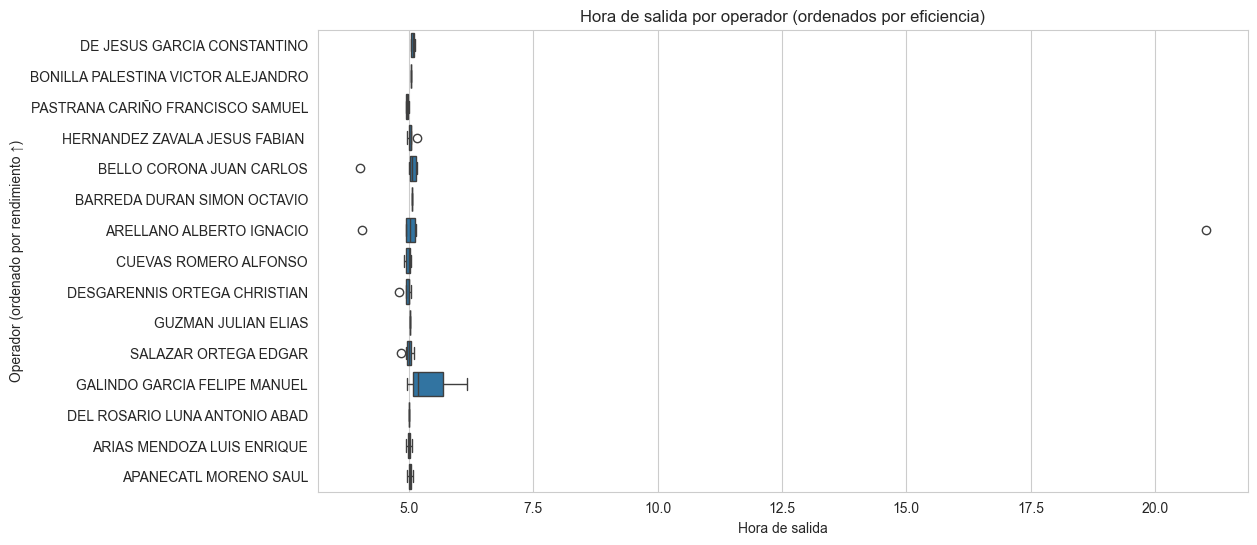

In [28]:
orden_rend = df.groupby('Operador')['Rend'].mean().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(x='hora_inicio_decimal', y='Operador', data=df, order=orden_rend, orient='h')
plt.xlabel('Hora de salida')
plt.ylabel('Operador (ordenado por rendimiento ↑)')
plt.title('Hora de salida por operador (ordenados por eficiencia)')
plt.show()

### Hipótesis: ¿La hora de salida explica el rendimiento?

**Resultado: NO.** La correlación hora-rendimiento es de -0.200 (débil), y el 
boxplot muestra que todos los operadores — eficientes e ineficientes — salen 
entre las 4:48 y 5:10 AM. No hay confusión entre hora y operador.

Hay un outlier nocturno (~21:00 hrs) con rendimiento bajo (2.1 km/L) que vale 
la pena investigar: ¿fue Arellano en tráfico de regreso, un viaje atípico, o 
un error de registro?

Esto fortalece la conclusión de que el factor dominante es el operador/unidad, 
no las condiciones del viaje.

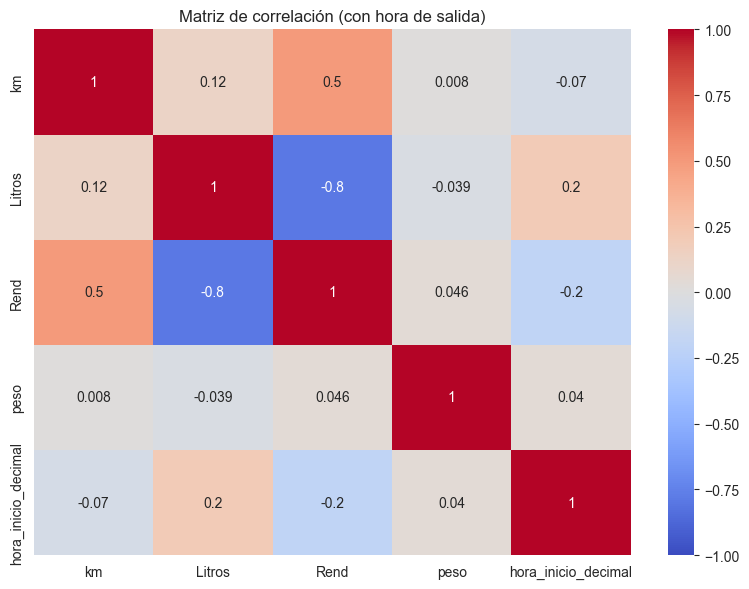

In [29]:
cols = ['km', 'Litros', 'Rend', 'peso', 'hora_inicio_decimal']
corr = df[cols].corr().round(3)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación (con hora de salida)')
plt.tight_layout()
plt.show()

## Duración del viaje

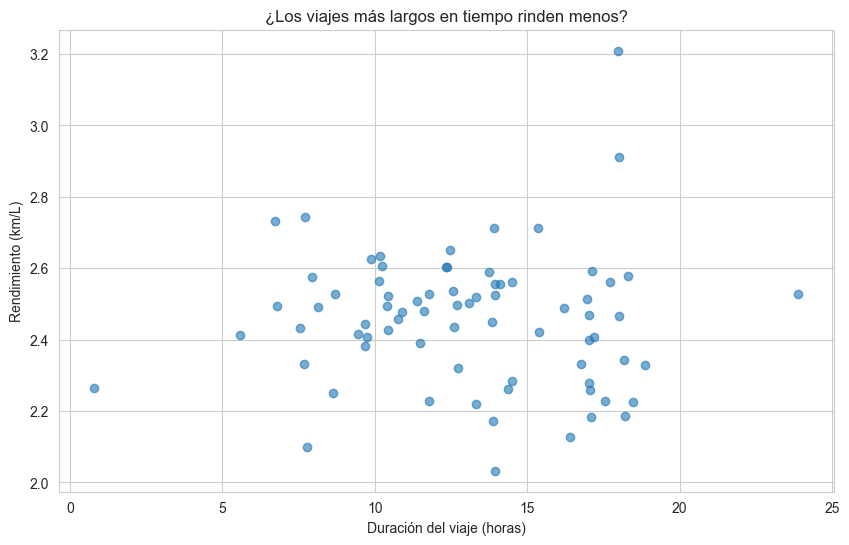

Correlación duración vs Rend: -0.011


In [31]:
df['hora_fin_decimal'] = df['Fin (Hora)'].apply(to_decimal_hour)
df['duracion_hrs'] = df['hora_fin_decimal'] - df['hora_inicio_decimal']
# Ajustar viajes que cruzan medianoche
df.loc[df['duracion_hrs'] < 0, 'duracion_hrs'] += 24

plt.scatter(df['duracion_hrs'], df['Rend'], alpha=0.6)
plt.xlabel('Duración del viaje (horas)')
plt.ylabel('Rendimiento (km/L)')
plt.title('¿Los viajes más largos en tiempo rinden menos?')
plt.show()
print(f"Correlación duración vs Rend: {df['duracion_hrs'].corr(df['Rend']):.3f}")

## Velocidad promedio

In [32]:
df['vel_promedio'] = df['km'] / df['duracion_hrs']

## Día de la semana

<Axes: xlabel='dia_semana', ylabel='Rend'>

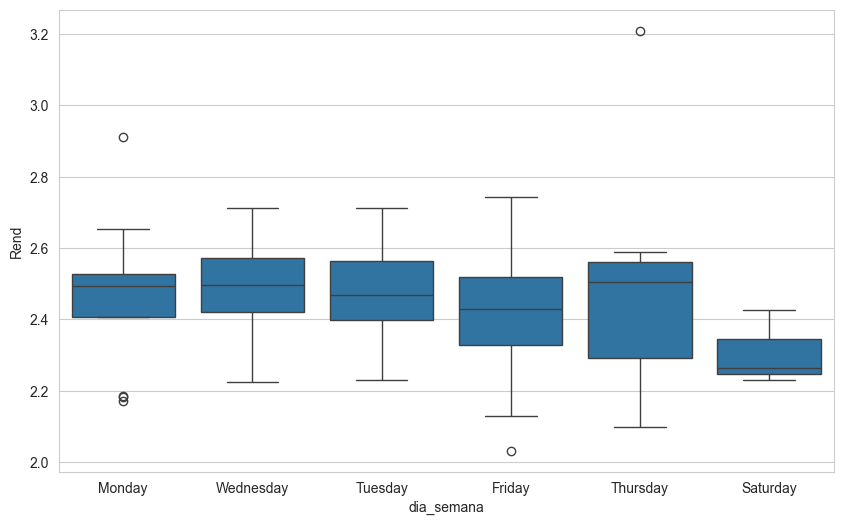

In [33]:
df['dia_semana'] = df['Fecha Inicio (Día)'].dt.day_name()
sns.boxplot(x='dia_semana', y='Rend', data=df)

## Consistencia del operador 

In [34]:
resumen = df.groupby('Operador').agg(
    viajes=('Rend', 'count'),
    rend_promedio=('Rend', 'mean'),
    rend_std=('Rend', 'std'),
    coef_variacion=('Rend', lambda x: x.std() / x.mean() * 100)
).sort_values('rend_promedio', ascending=False).round(3)
resumen

,viajes,rend_promedio,rend_std,coef_variacion
Operador,,,,
APANECATL MORENO SAUL,10,2.634,0.147,5.563
ARIAS MENDOZA LUIS ENRIQUE,7,2.624,0.261,9.941
DEL ROSARIO LUNA ANTONIO ABAD,1,2.590,NaN,NaN
GALINDO GARCIA FELIPE MANUEL,3,2.540,0.061,2.383
SALAZAR ORTEGA EDGAR,11,2.534,0.097,3.822
GUZMAN JULIAN ELIAS,1,2.527,NaN,NaN
DESGARENNIS ORTEGA CHRISTIAN,4,2.505,0.018,0.716
CUEVAS ROMERO ALFONSO,7,2.447,0.113,4.610
ARELLANO ALBERTO IGNACIO,6,2.404,0.189,7.850


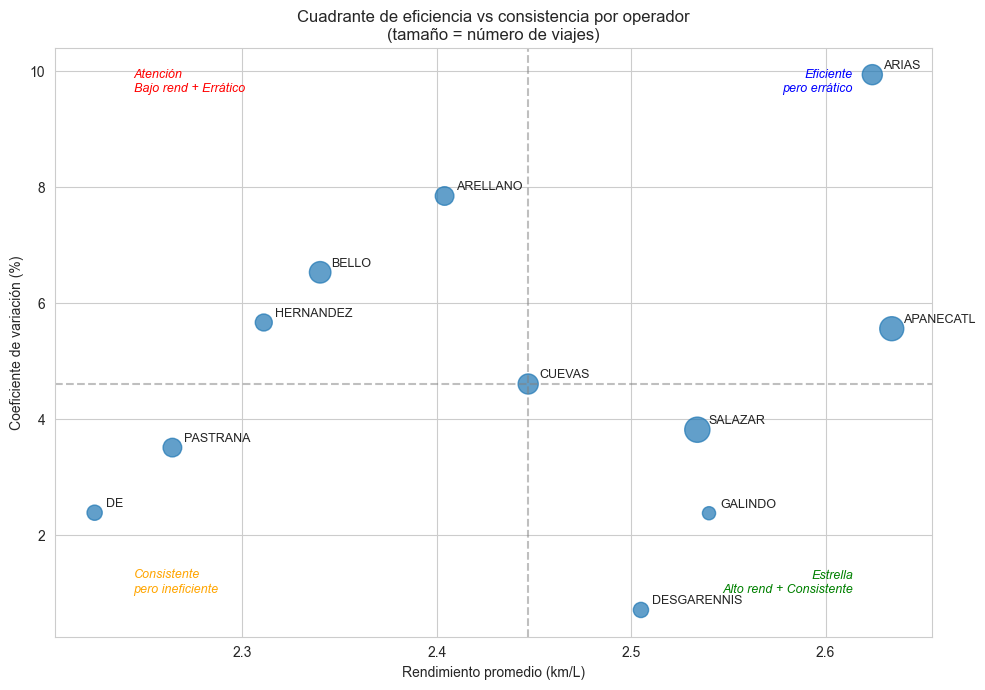

In [36]:
# Filtrar operadores con más de 1 viaje (los de 1 viaje tienen NaN en std)
resumen_filtrado = resumen.dropna()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(resumen_filtrado['rend_promedio'], resumen_filtrado['coef_variacion'], s=resumen_filtrado['viajes'] * 30, alpha=0.7)

# Etiquetas con apellido para que se lean
for operador, row in resumen_filtrado.iterrows():
    apellido = operador.split()[0]
    ax.annotate(apellido, (row['rend_promedio'], row['coef_variacion']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

# Líneas de referencia para los cuadrantes
med_rend = resumen_filtrado['rend_promedio'].median()
med_cv = resumen_filtrado['coef_variacion'].median()
ax.axvline(x=med_rend, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=med_cv, color='gray', linestyle='--', alpha=0.5)

# Etiquetas de cuadrantes
ax.text(resumen_filtrado['rend_promedio'].max() - 0.02, resumen_filtrado['coef_variacion'].min() + 0.3,
        'Estrella\nAlto rend + Consistente', ha='right', fontsize=9, color='green', fontstyle='italic')
ax.text(resumen_filtrado['rend_promedio'].min() + 0.02, resumen_filtrado['coef_variacion'].min() + 0.3,
        'Consistente\npero ineficiente', ha='left', fontsize=9, color='orange', fontstyle='italic')
ax.text(resumen_filtrado['rend_promedio'].max() - 0.02, resumen_filtrado['coef_variacion'].max() - 0.3,
        'Eficiente\npero errático', ha='right', fontsize=9, color='blue', fontstyle='italic')
ax.text(resumen_filtrado['rend_promedio'].min() + 0.02, resumen_filtrado['coef_variacion'].max() - 0.3,
        'Atención\nBajo rend + Errático', ha='left', fontsize=9, color='red', fontstyle='italic')

ax.set_xlabel('Rendimiento promedio (km/L)')
ax.set_ylabel('Coeficiente de variación (%)')
ax.set_title('Cuadrante de eficiencia vs consistencia por operador\n(tamaño = número de viajes)')
plt.tight_layout()
plt.show()

## Conclusiones del análisis exploratorio extendido

### Hipótesis investigadas

**1. ¿La hora de salida explica el rendimiento?**
NO. Correlación de -0.200 (débil). Casi todos los operadores salen entre 4:48 
y 5:10 AM — no hay variación suficiente para que la hora sea un factor. Se 
detectó un outlier nocturno (~21:00 hrs, rendimiento 2.1 km/L) que merece 
investigación individual.

**2. ¿La duración del viaje afecta el rendimiento?**
NO. Correlación de -0.011 (prácticamente cero). Hay viajes de 5 y de 24 horas 
con rendimientos similares. Se detectó un viaje con duración ~0 horas 
(probable error de registro o cruce de medianoche).

**3. ¿El día de la semana influye?**
NO. Los boxplots por día son casi idénticos. Sábado muestra rendimiento 
ligeramente menor pero con pocos datos para ser concluyente.

### Hallazgo principal: Cuadrante de eficiencia vs consistencia

El análisis de coeficiente de variación por operador reveló perfiles claros:

| Cuadrante | Operadores | Acción recomendada |
|-----------|-----------|-------------------|
| Estrella (alto rend + consistente) | Desgarennis, Galindo, Salazar | Modelo a seguir. Estudiar sus prácticas |
| Eficiente pero errático | Arias, Apanecatl | Buen potencial, necesitan estandarizar |
| Consistente pero ineficiente | De Jesús, Pastrana | Candidatos a capacitación — ya son disciplinados |
| Atención (bajo + errático) | Arellano, Bello | Prioridad de intervención |

### Resumen ejecutivo

De las variables analizadas — hora de salida, duración, día de la semana, 
peso y distancia — **ninguna explica la variabilidad en rendimiento**. El 
factor dominante sigue siendo quién maneja (y/o qué unidad usa).

Pero el cuadrante de eficiencia vs consistencia agrega una dimensión 
estratégica: no basta con identificar quién gasta más, sino quién es 
predecible. Esto permite a ORTA diseñar intervenciones diferenciadas — 
capacitación para los consistentes-ineficientes, estandarización para los 
eficientes-erráticos.